In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()
data['solarradiation'].fillna(mean_13_00, inplace=True)

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
kwh_data = data[['temp', 'solarradiation', 'Kwh']]
kwh_data

,temp,solarradiation,Kwh
datetime,,,
2022-01-01 00:00:00,6.0,0.0,0.0000
2022-01-01 01:00:00,6.0,0.0,0.0000
2022-01-01 02:00:00,4.9,0.0,0.0000
2022-01-01 03:00:00,4.0,0.0,0.0000
2022-01-01 04:00:00,3.0,0.0,0.0000
...,...,...,...
2024-07-04 19:00:00,24.0,207.0,0.0592
2024-07-04 20:00:00,23.0,103.0,0.0085
2024-07-04 21:00:00,21.0,9.0,0.0000


# LSTM Preprocess

In [5]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :3]]
        x.append(row)
        real_val = df_as_np[i + size][3]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [6]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :3])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)


,0,1,2
0,-0.844550,-0.667640,-0.679890
1,-0.844550,-0.667640,-0.679890
2,-0.969842,-0.667640,-0.679890
3,-1.072353,-0.667640,-0.679890
4,-1.186254,-0.667640,-0.679890
5,-1.186254,-0.667640,-0.679890
6,-1.072353,-0.667640,-0.679890
7,-0.844550,-0.667640,-0.679890
8,-0.958452,-0.644949,-0.542965
9,-0.844550,-0.580657,-0.234996


In [7]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2
datetime,,,
2022-01-01 00:00:00,-0.844550,-0.667640,-0.679890
2022-01-01 01:00:00,-0.844550,-0.667640,-0.679890
2022-01-01 02:00:00,-0.969842,-0.667640,-0.679890
2022-01-01 03:00:00,-1.072353,-0.667640,-0.679890
2022-01-01 04:00:00,-1.186254,-0.667640,-0.679890
...,...,...,...
2024-07-04 19:00:00,1.205675,0.115206,-0.414121
2024-07-04 20:00:00,1.091774,-0.278108,-0.641731
2024-07-04 21:00:00,0.863971,-0.633603,-0.679890


In [8]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,Kwh
datetime,,,,
2022-01-01 00:00:00,-0.844550,-0.667640,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,-0.667640,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,-0.667640,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,-0.667640,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,-0.667640,-0.679890,0.0000
...,...,...,...,...
2024-07-04 19:00:00,1.205675,0.115206,-0.414121,0.0592
2024-07-04 20:00:00,1.091774,-0.278108,-0.641731,0.0085
2024-07-04 21:00:00,0.863971,-0.633603,-0.679890,0.0000


In [9]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.9*len(x_kwh))], y_kwh[:int(0.9*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.9*len(x_kwh)):int(0.95*len(x_kwh))], y_kwh[int(0.9*len(y_kwh)):int(0.95*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.95*len(x_kwh)):], y_kwh[int(0.95*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((19763, 24, 3), (19763,), (1098, 24, 3), (1098,), (1098, 24, 3), (1098,))

In [10]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [11]:
input_shape = (24, 3)

inputs = Input(shape=input_shape)

cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

query = cnn_out
value = cnn_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

lstm_out = LSTM(128, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

dropout_out = Dropout(0.3)(multihead_attention_out)

dense_out = Dense(128, activation="relu")(dropout_out)

flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 12, 64)    │          0 │ conv1d[0][0]      │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 64)    │        256 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_1 │ (None, 6, 128)    │          0 │ conv1d_1[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 6, 128)    │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 128)    │    527,488 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 6, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 128)    │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 702,849 (2.68 MB)

 Trainable params: 701,953 (2.68 MB)

 Non-trainable params: 896 (3.50 KB)

In [12]:
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
616/618 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1876 - root_mean_squared_error: 0.3600
Epoch 1: val_loss improved from inf to 0.01344, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.1869 - root_mean_squared_error: 0.3592 - val_loss: 0.0134 - val_root_mean_squared_error: 0.1171 - learning_rate: 0.0010
Epoch 2/40
614/618 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0092 - root_mean_squared_error: 0.0957
Epoch 2: val_loss improved from 0.01344 to 0.00857, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0092 - root_mean_squared_error: 0.0956 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0935 - learning_rate: 0.0010
Epoch 3/40
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0060 - root_mean_squared_error: 0.0773
Epoch 3: val_loss improved from 0.00857 to 0.00761, saving model to D:/Σπουδέ

In [13]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-1098:].index

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


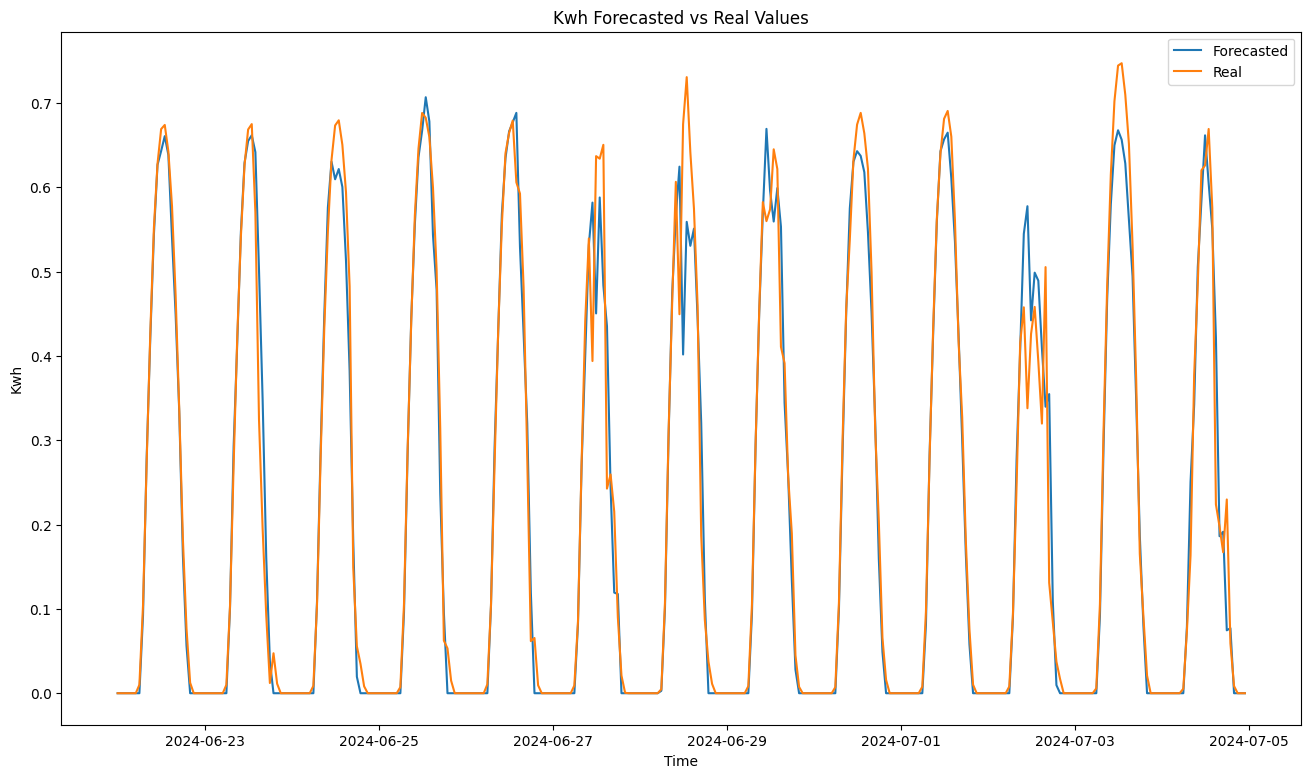

In [14]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][-13*24:], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][-13*24:], label="Real")
plt.legend()
plt.ylabel("Kwh")
plt.xlabel("Time")
plt.title("Kwh Forecasted vs Real Values")
plt.show()


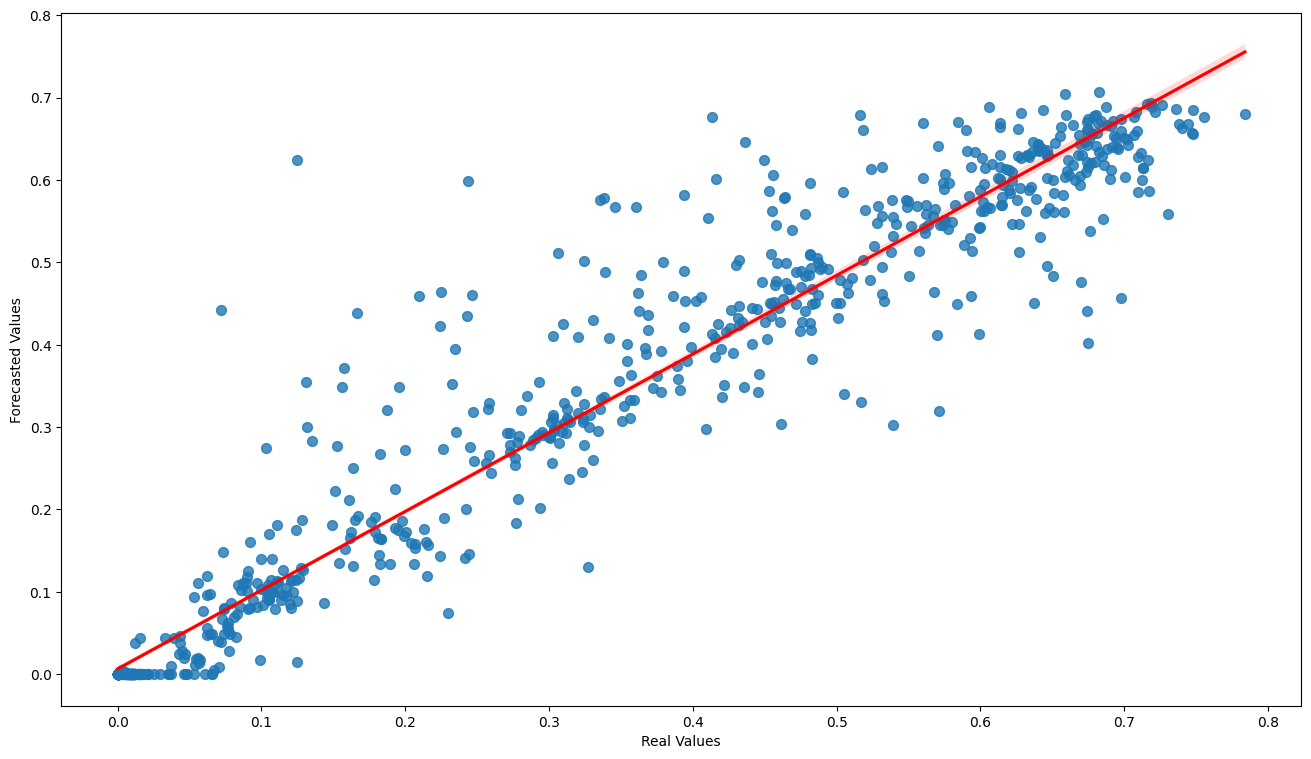

In [15]:
plt.figure(figsize= (16, 9))
sns.regplot(x="Real Data", y="Val Predictions", data=test_results_kwh, scatter_kws={'s': 50}, line_kws={'color': 'red', 'label': 'Regression Line'})
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [16]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)
mean_real_data = test_results_kwh["Real Data"].mean()
mse_percent = (mse_kwh / mean_real_data) * 100


r_squared_kwh, mse_kwh, mse_percent    #R^2 --> 0.9497

Mean Squared Error = 0.00336 
Root Mean Squared Error = 0.05801


(0.9487976365859602, 0.0033648442971928845, 1.5302133080953082)